# Physics-verified periorbital wearable for joint diabetic retinopathy and neuropathy screening
## Analysis notebook: datasets, models, digital twin and results

Structure follows the project's analysis protocol: PART 1 integrity checks, PART 2 cohort structure, PARTS 3 to 5 the fundus grader and its
transfer across populations, PART 6 the macular edema head, PART 7 the systemic (EHR) models with the leakage audit, PART 8 the
physiological branch, PART 9 the digital twin credibility numbers, PART 10 design verdicts and the audit summary.

Inputs: `results/RESULTS_MASTER.json` (single source of numbers, with the source file and key path of every entry) and the stored
per-subject predictions in `results/out/*.npz`. Training is done by the scripts in `results/src/` (see README). Outputs of this
notebook (CSV tables and PNG figures) are written to `results/notebooks/out/`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, pathlib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, cohen_kappa_score, confusion_matrix, brier_score_loss,
                             average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from scipy.stats import fisher_exact, spearmanr, mannwhitneyu

RS = 20260828
ROOT = pathlib.Path.cwd()
while not (ROOT / "results" / "RESULTS_MASTER.json").exists(): ROOT = ROOT.parent
OUT = ROOT / "results" / "out"; NBO = ROOT / "results" / "notebooks" / "out"; NBO.mkdir(parents=True, exist_ok=True)
M = json.loads((ROOT / "results" / "RESULTS_MASTER.json").read_text(encoding="utf-8"))
plt.rcParams["figure.dpi"] = 110

def v(*ks):
    """Read a value from the results master by key path."""
    d = M
    for k in ks: d = d[k]
    return d["value"] if isinstance(d, dict) and "value" in d else d

def ci(*ks):
    d = M
    for k in ks: d = d[k]
    return d.get("ci95")

def boot_auc(y, s, n=1000, seed=RS):
    rng = np.random.default_rng(seed); y = np.asarray(y); s = np.asarray(s); out = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1: out.append(roc_auc_score(y[i], s[i]))
    return np.percentile(out, [2.5, 97.5])

def grade(score, th): return np.digitize(score, np.sort(np.asarray(th)))
def banner(t): print("=" * 78); print(t); print("=" * 78)
print("results master built:", M["_meta"]["built"], "| sections:", len(M))

results master built: 2026-09-08T07:46:29 | sections: 20


In [2]:
banner("PART 1  INTEGRITY  (numbers reproduce from stored predictions; leakage and quantum audits)")
# npz files are this project's own outputs (object arrays hold image paths), so allow_pickle is safe here
Z = np.load(OUT / "fundus_oof.npz", allow_pickle=True); I = np.load(OUT / "fundus_idrid_pred.npz", allow_pickle=True)
A = np.load(OUT / "fundus_aptos_pred.npz", allow_pickle=True); Dm = np.load(OUT / "dme_idrid_pred.npz")
E = np.load(OUT / "ehr_oof.npz"); H = np.load(OUT / "hrv_pred.npz"); P = np.load(OUT / "ppg_pred.npz")
th = np.array(v("fundus_dr", "thresholds")); m = ~np.isnan(Z["oof"])
checks = [
    ("DeepDRiD OOF QWK", cohen_kappa_score(Z["grade"][m], grade(Z["oof"][m], th), weights="quadratic"), v("fundus_dr", "qwk")),
    ("DeepDRiD OOF referable AUC", roc_auc_score(Z["grade"][m] >= 2, Z["oof"][m]), v("fundus_dr", "auc_referable")),
    ("IDRiD QWK", cohen_kappa_score(I["grade"], grade(I["pred"], th), weights="quadratic"), v("fundus_external_idrid", "qwk")),
    ("APTOS QWK", cohen_kappa_score(A["grade"], grade(A["pred"], th), weights="quadratic"), v("fundus_external_aptos", "qwk")),
    ("APTOS referable AUC", roc_auc_score(A["grade"] >= 2, A["pred"]), v("fundus_external_aptos", "auc_referable")),
    ("DME test QWK", cohen_kappa_score(Dm["y_test"], grade(Dm["test_pred"], v("dme", "thresholds")), weights="quadratic"), v("dme", "test_qwk")),
    ("EHR retinopathy AUC (boosted)", roc_auc_score(E["y_dr"], E["retinopathy_hgb"]), v("ehr", "retinopathy", "hgb", "auc")),
    ("EHR neuropathy AUC (boosted, proxies excluded)", roc_auc_score(E["y_dn"], E["diabetic_neuropathy_hgb"]), v("ehr", "headline_dn_auc")),
    ("HRV diabetes vs control AUC", roc_auc_score(H["dm_vs_control_y"], H["dm_vs_control_p"]), v("hrv", "dm_vs_control", "auc")),
    ("PPG-BP hypertension control AUC", roc_auc_score(P["htn_morphology_y"], P["htn_morphology_p"]), v("ppg", "hypertension_auc_by_route", "morphology")),
]
t1 = pd.DataFrame(checks, columns=["Quantity", "Recomputed here", "Results master"]); t1["Agree"] = np.isclose(t1["Recomputed here"], t1["Results master"], atol=1e-6)
print(t1.round(4).to_string(index=False)); t1.to_csv(NBO / "R1_Integrity.csv", index=False)
print(f"\n  All {int(t1['Agree'].sum())}/{len(t1)} quantities reproduce exactly from the stored predictions.")
print("  Leakage audit: the neuropathy model excludes", v("datasets", "istanbul_ehr", "excluded_as_dn_treatment_proxy"))
print("  and the outcome-carrying columns", v("datasets", "istanbul_ehr", "excluded_as_leakage"))
print("  Quantum audit:", M["_meta"]["no_quantum"])

PART 1  INTEGRITY  (numbers reproduce from stored predictions; leakage and quantum audits)
                                      Quantity  Recomputed here  Results master  Agree
                              DeepDRiD OOF QWK           0.8571          0.8571   True
                    DeepDRiD OOF referable AUC           0.9698          0.9698   True
                                     IDRiD QWK           0.7294          0.7294   True
                                     APTOS QWK           0.8452          0.8452   True
                           APTOS referable AUC           0.9792          0.9792   True
                                  DME test QWK           0.8381          0.8381   True
                 EHR retinopathy AUC (boosted)           0.7203          0.7203   True
EHR neuropathy AUC (boosted, proxies excluded)           0.7100          0.7100   True
                   HRV diabetes vs control AUC           0.7768          0.7768   True
               PPG-BP hypertension cont

PART 2  COHORT STRUCTURE  (what the datasets contain)
 ICDR grade  DeepDRiD (China, n=1,589)  IDRiD (India, n=516)  APTOS 2019 (India, n=3,662)  DeepDRiD (China, n=1,589) %  IDRiD (India, n=516) %  APTOS 2019 (India, n=3,662) %
          0                        706                   168                         1805                         44.4                    32.6                           49.3
          1                        185                    25                          370                         11.6                     4.8                           10.1
          2                        324                   168                          999                         20.4                    32.6                           27.3
          3                        282                    93                          193                         17.7                    18.0                            5.3
          4                         92                    62                

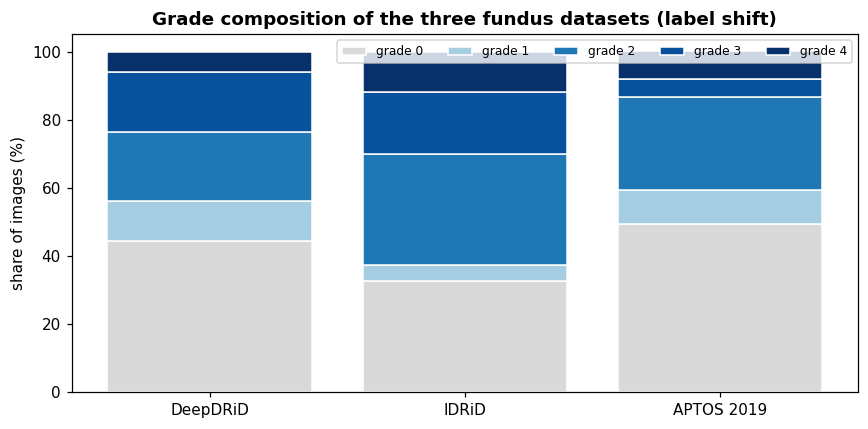

In [3]:
banner("PART 2  COHORT STRUCTURE  (what the datasets contain)")
gc = lambda d: [int(x) for x in v(*d).values()]
t2 = pd.DataFrame({"ICDR grade": [0, 1, 2, 3, 4],
                   "DeepDRiD (China, n=1,589)": gc(("fundus_dr", "grade_counts")),
                   "IDRiD (India, n=516)": gc(("datasets", "idrid", "grade_counts")),
                   "APTOS 2019 (India, n=3,662)": gc(("fundus_external_aptos", "grade_counts"))})
for c in t2.columns[1:]: t2[c + " %"] = (100 * t2[c] / t2[c].sum()).round(1)
print(t2.to_string(index=False)); t2.to_csv(NBO / "R2_GradeDistributions.csv", index=False)
print(f"\n  Referable share (grade >= 2): DeepDRiD {100*(Z['grade'][m]>=2).mean():.1f} %   IDRiD {100*(I['grade']>=2).mean():.1f} %   APTOS {100*(A['grade']>=2).mean():.1f} %")
print(f"  EHR cohort n = {v('ehr','retinopathy','n'):,}: retinopathy prevalence {100*v('ehr','retinopathy','prevalence'):.2f} %,"
      f" neuropathy prevalence {100*v('ehr','diabetic_neuropathy_main_excludes_treatment_proxies','prevalence'):.2f} %")
jc = v("ehr", "joint_counts"); print("  Joint outcome counts (none / DR only / DN only / both):", [jc[k] for k in ("0", "1", "2", "3")])
print(f"  HRV cohorts: n = {v('hrv','pooled_n')} records, {v('hrv','dm_vs_control','n_pos')} with diabetes; retinopathy label on {v('hrv','dr_within_dm','n')} ({v('hrv','dr_within_dm','n_dr')} DR+)")
print(f"  PPG-BP: n = {v('ppg','n_subjects')} subjects, {v('ppg','n_diabetic')} with type 2 diabetes, {v('ppg','hypertension_n_pos')} hypertensive")
fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(3); shades = ["#d9d9d9", "#a6cee3", "#1f78b4", "#08519c", "#08306b"]; names = ["DeepDRiD", "IDRiD", "APTOS 2019"]
for g in range(5):
    vals = [t2.iloc[g][c + " %"] for c in t2.columns[1:4]]; ax.bar(names, vals, bottom=bottom, color=shades[g], label=f"grade {g}", edgecolor="white"); bottom += vals
ax.set_ylabel("share of images (%)"); ax.set_title("Grade composition of the three fundus datasets (label shift)", fontweight="bold"); ax.legend(ncol=5, fontsize=8)
plt.tight_layout(); plt.savefig(NBO / "R_Fig1_GradeComposition.png", dpi=300, bbox_inches="tight"); plt.show()

PART 3  PRIMARY  --  fundus grading on DeepDRiD (patient-grouped 5-fold, out of fold)
  n = 1589 images from 399 patients; thresholds fitted on OOF scores: [0.527, 1.504, 2.499, 3.49]
  QWK 0.857 [0.8348696995260773, 0.8776324753621546]   referable AUC 0.970 [0.9593630071258558, 0.9790624263586815]   accuracy 0.685
  Per-grade recall: {0: np.float64(0.785), 1: np.float64(0.486), 2: np.float64(0.605), 3: np.float64(0.794), 4: np.float64(0.261)}

  Confusion matrix (rows true, columns predicted):
        pred 0  pred 1  pred 2  pred 3  pred 4
true 0     554     115      33       3       1
true 1      72      90      22       1       0
true 2      12      50     196      66       0
true 3       1       4      50     224       3
true 4       0       2      15      51      24

  Final-epoch validation QWK per fold: [0.854, 0.847, 0.832, 0.839, 0.841]


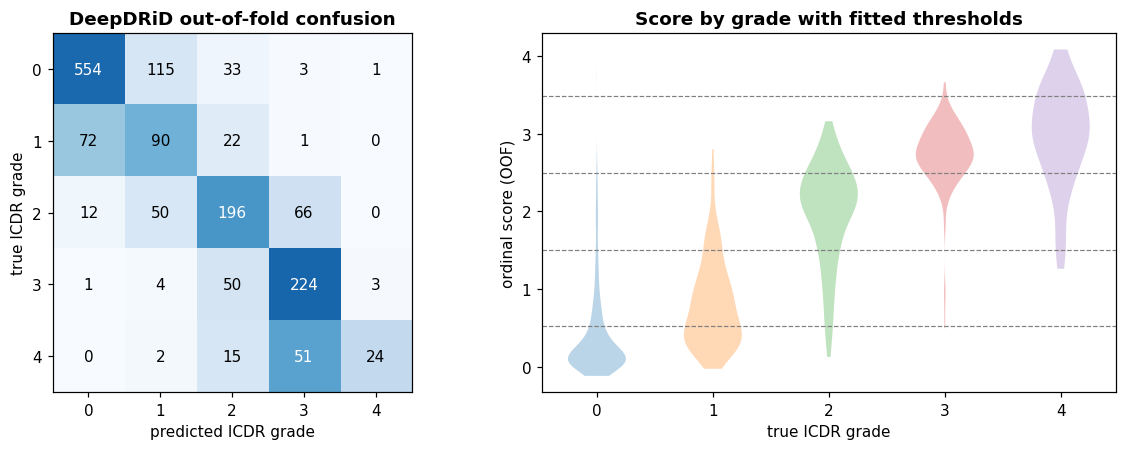

In [4]:
banner("PART 3  PRIMARY  --  fundus grading on DeepDRiD (patient-grouped 5-fold, out of fold)")
y, s = Z["grade"][m], Z["oof"][m]; g = grade(s, th)
cm = confusion_matrix(y, g, labels=range(5))
print(f"  n = {len(y)} images from {v('fundus_dr','cv','n_patients') if False else 399} patients; thresholds fitted on OOF scores: {np.round(th, 3).tolist()}")
print(f"  QWK {cohen_kappa_score(y, g, weights='quadratic'):.3f} {ci('fundus_dr','qwk')}   referable AUC {roc_auc_score(y>=2, s):.3f} {ci('fundus_dr','auc_referable')}   accuracy {(g==y).mean():.3f}")
print("  Per-grade recall:", dict(zip(range(5), (np.diag(cm) / cm.sum(1)).round(3))))
print("\n  Confusion matrix (rows true, columns predicted):"); print(pd.DataFrame(cm, index=[f"true {i}" for i in range(5)], columns=[f"pred {j}" for j in range(5)]).to_string())
folds = v("fundus_dr", "fold_final_epoch_val_qwk"); print("\n  Final-epoch validation QWK per fold:", np.round(folds, 3).tolist())
pd.DataFrame(cm).to_csv(NBO / "R3_DeepDRiD_Confusion.csv")
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
im = ax[0].imshow(cm / cm.sum(1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5): ax[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] / cm[i].sum() > 0.5 else "black")
ax[0].set_xlabel("predicted ICDR grade"); ax[0].set_ylabel("true ICDR grade"); ax[0].set_title("DeepDRiD out-of-fold confusion", fontweight="bold")
for gg in range(5): ax[1].violinplot([s[y == gg]], positions=[gg], showextrema=False)
for t_ in th: ax[1].axhline(t_, ls="--", color="grey", lw=0.8)
ax[1].set_xlabel("true ICDR grade"); ax[1].set_ylabel("ordinal score (OOF)"); ax[1].set_title("Score by grade with fitted thresholds", fontweight="bold")
plt.tight_layout(); plt.savefig(NBO / "R_Fig2_DeepDRiD.png", dpi=300, bbox_inches="tight"); plt.show()

PART 4  PRIMARY  --  transfer to two Indian populations with the DeepDRiD thresholds unchanged


                    Dataset    n   QWK  AUC referable  AUC 95% lo  AUC 95% hi  Accuracy  Sensitivity  Specificity
       DeepDRiD OOF (China) 1589 0.857          0.970       0.963       0.977     0.685        0.901        0.933
     IDRiD external (India)  516 0.729          0.952       0.933       0.967     0.450        0.938        0.715
APTOS 2019 external (India) 3662 0.845          0.979       0.975       0.983     0.552        0.990        0.848

  Re-fitted thresholds (diagnostic only, NOT used): APTOS QWK 0.878, IDRiD QWK 0.769
  Interpretation: the ordering transfers (AUC 0.95 to 0.98); the grade boundaries do not (accuracy 45 to 55 %).


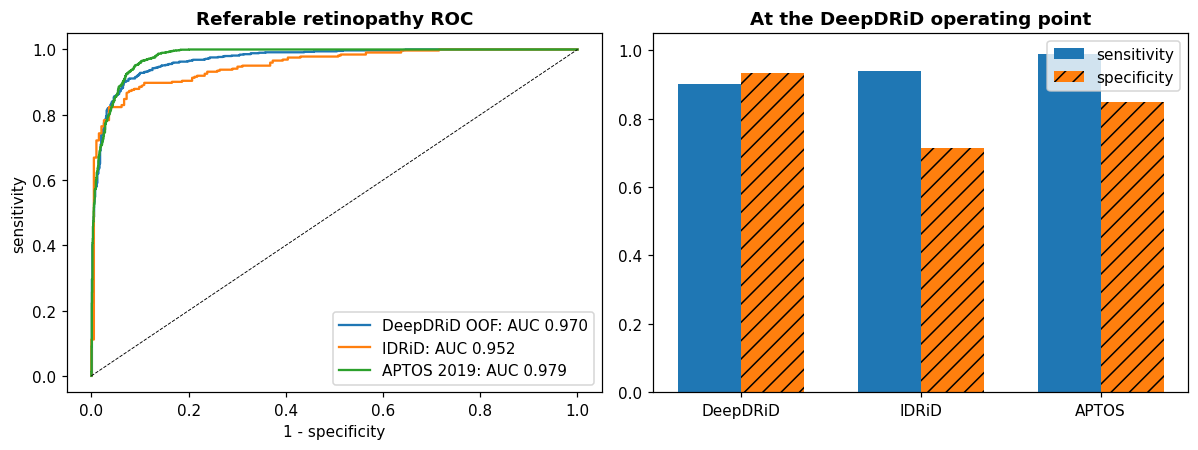

In [5]:
banner("PART 4  PRIMARY  --  transfer to two Indian populations with the DeepDRiD thresholds unchanged")
rows = []
for name, yy, ss in (("DeepDRiD OOF (China)", y, s), ("IDRiD external (India)", I["grade"], I["pred"]), ("APTOS 2019 external (India)", A["grade"], A["pred"])):
    gg = grade(ss, th); lo, hi = boot_auc(yy >= 2, ss)
    rows.append({"Dataset": name, "n": len(yy), "QWK": cohen_kappa_score(yy, gg, weights="quadratic"), "AUC referable": roc_auc_score(yy >= 2, ss),
                 "AUC 95% lo": lo, "AUC 95% hi": hi, "Accuracy": (gg == yy).mean(),
                 "Sensitivity": ((gg >= 2) & (yy >= 2)).sum() / (yy >= 2).sum(), "Specificity": ((gg < 2) & (yy < 2)).sum() / (yy < 2).sum()})
t4 = pd.DataFrame(rows); print(t4.round(3).to_string(index=False)); t4.to_csv(NBO / "R4_Transfer.csv", index=False)
print(f"\n  Re-fitted thresholds (diagnostic only, NOT used): APTOS QWK {v('fundus_external_aptos','refit_qwk_not_used'):.3f}, IDRiD QWK {v('fundus_external_idrid','refit_qwk_not_used'):.3f}")
print("  Interpretation: the ordering transfers (AUC 0.95 to 0.98); the grade boundaries do not (accuracy 45 to 55 %).")
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, yy, ss in (("DeepDRiD OOF", y, s), ("IDRiD", I["grade"], I["pred"]), ("APTOS 2019", A["grade"], A["pred"])):
    f, t_, _ = roc_curve(yy >= 2, ss); ax[0].plot(f, t_, label=f"{name}: AUC {roc_auc_score(yy>=2, ss):.3f}")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.6); ax[0].set_xlabel("1 - specificity"); ax[0].set_ylabel("sensitivity"); ax[0].legend(); ax[0].set_title("Referable retinopathy ROC", fontweight="bold")
x = np.arange(3); w = 0.35
ax[1].bar(x - w/2, t4["Sensitivity"], w, label="sensitivity"); ax[1].bar(x + w/2, t4["Specificity"], w, label="specificity", hatch="//")
ax[1].set_xticks(x); ax[1].set_xticklabels(["DeepDRiD", "IDRiD", "APTOS"]); ax[1].set_ylim(0, 1.05); ax[1].legend(); ax[1].set_title("At the DeepDRiD operating point", fontweight="bold")
plt.tight_layout(); plt.savefig(NBO / "R_Fig3_Transfer.png", dpi=300, bbox_inches="tight"); plt.show()

PART 5  PRIMARY  --  error mechanism: is the external error a boundary shift or a loss of ordering?
     Dataset  graded above label (%)  exact (%)  graded below label (%)  mean shift (grades)  off by one only (%)  off by two or more (%)
DeepDRiD OOF                   15.36      68.47                   16.17                -0.00                27.00                    4.53
       IDRiD                   38.18      44.96                   16.86                 0.29                44.77                   10.27
  APTOS 2019                   36.46      55.16                    8.38                 0.29                42.08                    2.76

  APTOS: true 2 -> predicted 3 in 641/999 (64 %); true 4 -> predicted 3 in 255/295 (86 %); true 1 -> predicted 2 in 257/370 (69 %)
  Interpretation: errors are one step upward and systematic, the signature of a threshold shift, not random confusion.


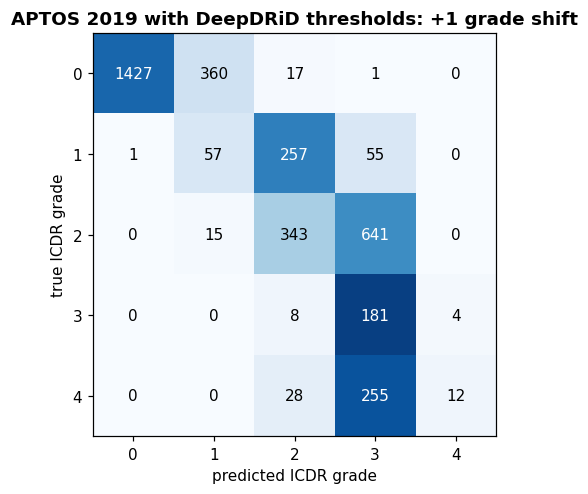

In [6]:
banner("PART 5  PRIMARY  --  error mechanism: is the external error a boundary shift or a loss of ordering?")
rows = []
for name, yy, ss in (("DeepDRiD OOF", y, s), ("IDRiD", I["grade"], I["pred"]), ("APTOS 2019", A["grade"], A["pred"])):
    gg = grade(ss, th); d = gg - yy
    rows.append({"Dataset": name, "graded above label (%)": 100 * (d > 0).mean(), "exact (%)": 100 * (d == 0).mean(), "graded below label (%)": 100 * (d < 0).mean(),
                 "mean shift (grades)": d.mean(), "off by one only (%)": 100 * (np.abs(d) == 1).mean(), "off by two or more (%)": 100 * (np.abs(d) >= 2).mean()})
t5 = pd.DataFrame(rows); print(t5.round(2).to_string(index=False)); t5.to_csv(NBO / "R5_ErrorMechanism.csv", index=False)
cma = confusion_matrix(A["grade"], grade(A["pred"], th), labels=range(5))
print(f"\n  APTOS: true 2 -> predicted 3 in {cma[2,3]}/{cma[2].sum()} ({100*cma[2,3]/cma[2].sum():.0f} %); true 4 -> predicted 3 in {cma[4,3]}/{cma[4].sum()} ({100*cma[4,3]/cma[4].sum():.0f} %);"
      f" true 1 -> predicted 2 in {cma[1,2]}/{cma[1].sum()} ({100*cma[1,2]/cma[1].sum():.0f} %)")
print("  Interpretation: errors are one step upward and systematic, the signature of a threshold shift, not random confusion.")
fig, ax = plt.subplots(figsize=(6, 4.6))
im = ax.imshow(cma / cma.sum(1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5): ax.text(j, i, cma[i, j], ha="center", va="center", color="white" if cma[i, j] / cma[i].sum() > 0.5 else "black")
ax.set_xlabel("predicted ICDR grade"); ax.set_ylabel("true ICDR grade"); ax.set_title("APTOS 2019 with DeepDRiD thresholds: +1 grade shift", fontweight="bold")
plt.tight_layout(); plt.savefig(NBO / "R_Fig4_APTOS_Shift.png", dpi=300, bbox_inches="tight"); plt.show()

In [7]:
banner("PART 6  MACULAR EDEMA HEAD  (IDRiD, DME grade 0 to 2)")
thd = np.array(v("dme", "thresholds"))
print(f"  5-fold OOF on 413 training images: QWK {cohen_kappa_score(Dm['y_train'], grade(Dm['oof'], thd), weights='quadratic'):.3f} {ci('dme','cv_qwk')}   any-DME AUC {roc_auc_score(Dm['y_train']>=1, Dm['oof']):.3f}")
print(f"  Fixed 103-image test split:      QWK {cohen_kappa_score(Dm['y_test'], grade(Dm['test_pred'], thd), weights='quadratic'):.3f} {ci('dme','test_qwk')}   any-DME AUC {roc_auc_score(Dm['y_test']>=1, Dm['test_pred']):.3f}")
ct = pd.crosstab(pd.Series(I["grade"], name="DR grade"), pd.Series(I["dme"], name="DME grade")); print("\n  DR grade x DME grade on all 516 IDRiD images:"); print(ct.to_string())
anyd = I["dme"] >= 1
print(f"\n  Any DME in {100*anyd[I['grade']>=2].mean():.1f} % of referable eyes and {100*anyd[I['grade']<2].mean():.1f} % of non-referable eyes")
paths = np.array([str(p) for p in I["path"]]); test = np.array(["Testing" in p for p in paths])
print(f"  Pearson r between the DR head and the DME head scores on the test split: {np.corrcoef(I['pred'][test], Dm['test_pred'])[0,1]:.2f}")
ct.to_csv(NBO / "R6_DR_by_DME.csv")

PART 6  MACULAR EDEMA HEAD  (IDRiD, DME grade 0 to 2)
  5-fold OOF on 413 training images: QWK 0.916 [0.8859175875911153, 0.9439420992727684]   any-DME AUC 0.982
  Fixed 103-image test split:      QWK 0.838 [0.7241080820260619, 0.9210368976800022]   any-DME AUC 0.945

  DR grade x DME grade on all 516 IDRiD images:
DME grade    0   1    2
DR grade               
0          168   0    0
1           25   0    0
2           16  36  116
3            6   7   80
4            7   8   47

  Any DME in 91.0 % of referable eyes and 0.0 % of non-referable eyes
  Pearson r between the DR head and the DME head scores on the test split: 0.77


PART 7  SYSTEMIC BRANCH  --  routine records, n = 77,724, with the leakage audit


                                                      Model  AUC (5-fold OOF)  AUPRC  Brier  Calibration slope  Intercept
                                      Retinopathy, logistic             0.710  0.278  0.112              0.975     -0.042
                                       Retinopathy, boosted             0.720  0.294  0.111              1.020      0.036
                    Neuropathy, logistic (proxies excluded)             0.703  0.330  0.132              0.978     -0.032
         Neuropathy, boosted (proxies excluded)  [REPORTED]             0.710  0.337  0.131              1.034      0.050
           Sensitivity A: neuropathy WITH treatment proxies             0.838  0.541  0.106              1.029      0.034
Sensitivity B: also without analgesics and psychoanaleptics             0.708  0.333  0.132              1.034      0.051

  With proxies restored the two proxy classes carry odds ratios per SD of 2.46 (ATC A16, alpha-lipoic acid) and 2.10 (N03, gabapentin/pregabalin)

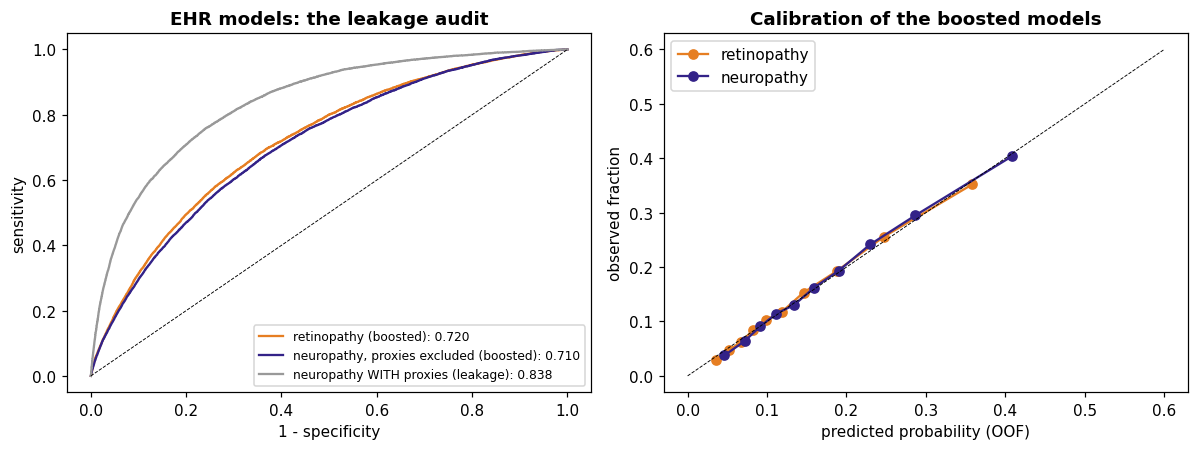

In [8]:
banner("PART 7  SYSTEMIC BRANCH  --  routine records, n = 77,724, with the leakage audit")
rows = []
for name, yy, pp in (("Retinopathy, logistic", E["y_dr"], E["retinopathy_logistic"]), ("Retinopathy, boosted", E["y_dr"], E["retinopathy_hgb"]),
                     ("Neuropathy, logistic (proxies excluded)", E["y_dn"], E["diabetic_neuropathy_logistic"]), ("Neuropathy, boosted (proxies excluded)  [REPORTED]", E["y_dn"], E["diabetic_neuropathy_hgb"]),
                     ("Sensitivity A: neuropathy WITH treatment proxies", E["y_dn"], E["DN_with_proxies_hgb"]), ("Sensitivity B: also without analgesics and psychoanaleptics", E["y_dn"], E["DN_wide_exclusion_hgb"])):
    lo_ = np.clip(pp, 1e-6, 1 - 1e-6); lg = np.log(lo_ / (1 - lo_)); cal = LogisticRegression(max_iter=2000).fit(lg.reshape(-1, 1), yy)
    rows.append({"Model": name, "AUC (5-fold OOF)": roc_auc_score(yy, pp), "AUPRC": average_precision_score(yy, pp), "Brier": brier_score_loss(yy, pp),
                 "Calibration slope": float(cal.coef_[0][0]), "Intercept": float(cal.intercept_[0])})
t7 = pd.DataFrame(rows); print(t7.round(3).to_string(index=False)); t7.to_csv(NBO / "R7_EHR_Models.csv", index=False)
orp = v("ehr", "dn_sensitivity_with_treatment_proxies", "logistic_odds_ratio_per_sd_top")
print(f"\n  With proxies restored the two proxy classes carry odds ratios per SD of {orp['other_digestive']:.2f} (ATC A16, alpha-lipoic acid) and {orp['antiepileptics']:.2f} (N03, gabapentin/pregabalin).")
print(f"  Removing them costs {roc_auc_score(E['y_dn'], E['DN_with_proxies_hgb']) - roc_auc_score(E['y_dn'], E['diabetic_neuropathy_hgb']):.3f} of AUC; the reported model reads the records as they look before neuropathic pain is treated.")
tab = np.array(v("ehr", "dr_dn_table")); orr, pf = fisher_exact(tab)
print(f"\n  DR x DN 2x2 table {tab.tolist()}: odds ratio {orr:.2f}, Fisher exact p = {pf:.2e}")
jo = v("ehr", "joint_ovr_auc"); print("  Joint 4-class one-vs-rest AUC:", {k: round(x, 3) for k, x in jo.items()})
top_dr = v("ehr", "retinopathy", "logistic_odds_ratio_per_sd_top"); top_dn = v("ehr", "diabetic_neuropathy_main_excludes_treatment_proxies", "logistic_odds_ratio_per_sd_top")
t7b = pd.DataFrame({"Retinopathy: feature": list(top_dr)[:8], "OR per SD": [round(x, 3) for x in list(top_dr.values())[:8]],
                    "Neuropathy: feature": list(top_dn)[:8], "OR per SD ": [round(x, 3) for x in list(top_dn.values())[:8]]})
print("\n  Top logistic odds ratios per standard deviation:"); print(t7b.to_string(index=False)); t7b.to_csv(NBO / "R7_OddsRatios.csv", index=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, yy, pp, c in (("retinopathy (boosted)", E["y_dr"], E["retinopathy_hgb"], "#e67e22"), ("neuropathy, proxies excluded (boosted)", E["y_dn"], E["diabetic_neuropathy_hgb"], "#332288"),
                        ("neuropathy WITH proxies (leakage)", E["y_dn"], E["DN_with_proxies_hgb"], "#999999")):
    f, t_, _ = roc_curve(yy, pp); ax[0].plot(f, t_, color=c, label=f"{name}: {roc_auc_score(yy, pp):.3f}")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.6); ax[0].legend(fontsize=8); ax[0].set_xlabel("1 - specificity"); ax[0].set_ylabel("sensitivity"); ax[0].set_title("EHR models: the leakage audit", fontweight="bold")
for name, yy, pp, c in (("retinopathy", E["y_dr"], E["retinopathy_hgb"], "#e67e22"), ("neuropathy", E["y_dn"], E["diabetic_neuropathy_hgb"], "#332288")):
    pt, pv = calibration_curve(yy, pp, n_bins=10, strategy="quantile"); ax[1].plot(pv, pt, "o-", color=c, label=name)
ax[1].plot([0, 0.6], [0, 0.6], "k--", lw=0.6); ax[1].set_xlabel("predicted probability (OOF)"); ax[1].set_ylabel("observed fraction"); ax[1].legend(); ax[1].set_title("Calibration of the boosted models", fontweight="bold")
plt.tight_layout(); plt.savefig(NBO / "R_Fig5_EHR.png", dpi=300, bbox_inches="tight"); plt.show()

PART 8  PHYSIOLOGICAL BRANCH  --  one positive result and two nulls with positive controls


                                               Analysis   n  n positive   AUC  95% lo  95% hi
                HRV: diabetes vs control (LOO logistic)  94          69 0.777   0.671   0.870
        HRV: retinopathy within diabetics (LOO)  [NULL]  58          19 0.367   0.212   0.520
                          HRV: autonomic symptoms (LOO)  51          15 0.541   0.334   0.735
     PPG-BP diabetes: demographics only (age, sex, BMI) 219          38 0.572   0.478   0.675
  PPG-BP diabetes: 11 pulse-morphology features  [NULL] 219          38 0.372   0.283   0.467
             PPG-BP diabetes: morphology + demographics 219          38 0.417   0.323   0.521
           PPG-BP diabetes: PaPaGei-S embedding, PCA-16 219          38 0.451   0.350   0.541
                PPG-BP diabetes: PaPaGei + demographics 219          38 0.490   0.389   0.587
PPG-BP hypertension from morphology  [POSITIVE CONTROL] 219         139 0.726   0.653   0.802

  Per-feature effects for retinopathy within diabetics (n =

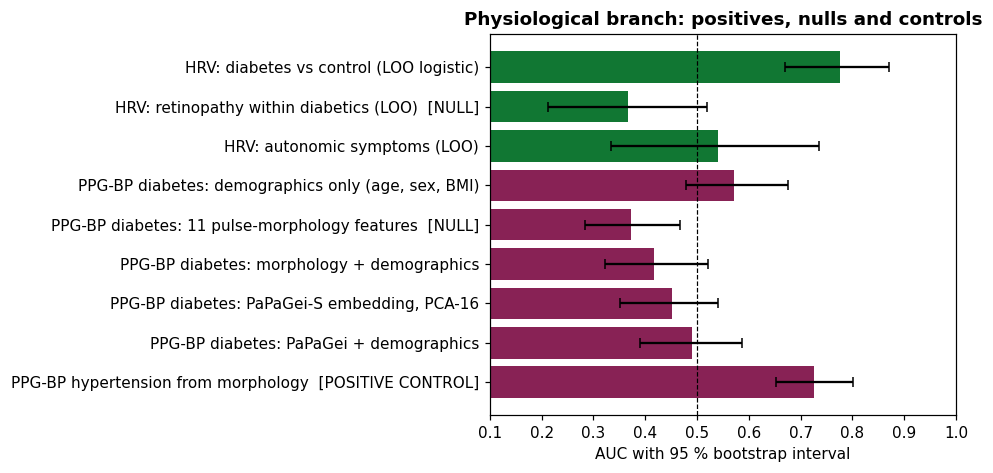

In [9]:
banner("PART 8  PHYSIOLOGICAL BRANCH  --  one positive result and two nulls with positive controls")
rows = [("HRV: diabetes vs control (LOO logistic)", H["dm_vs_control_y"], H["dm_vs_control_p"]), ("HRV: retinopathy within diabetics (LOO)  [NULL]", H["dr_within_dm_y"], H["dr_within_dm_p"]),
        ("HRV: autonomic symptoms (LOO)", H["autonomic_symptoms_y"], H["autonomic_symptoms_p"])]
for k, lab in (("dm_demographics_only", "PPG-BP diabetes: demographics only (age, sex, BMI)"), ("dm_morphology", "PPG-BP diabetes: 11 pulse-morphology features  [NULL]"),
               ("dm_morphology_plus_demo", "PPG-BP diabetes: morphology + demographics"), ("dm_papagei_pca16", "PPG-BP diabetes: PaPaGei-S embedding, PCA-16"),
               ("dm_papagei_plus_demo", "PPG-BP diabetes: PaPaGei + demographics"), ("htn_morphology", "PPG-BP hypertension from morphology  [POSITIVE CONTROL]")):
    rows.append((lab, P[k + "_y"], P[k + "_p"]))
t8 = pd.DataFrame([{"Analysis": n, "n": len(yy), "n positive": int(yy.sum()), "AUC": roc_auc_score(yy, pp), "95% lo": boot_auc(yy, pp)[0], "95% hi": boot_auc(yy, pp)[1]} for n, yy, pp in rows])
print(t8.round(3).to_string(index=False)); t8.to_csv(NBO / "R8_Physiological.csv", index=False)
eff = v("hrv", "dr_within_dm", "effects")
t8b = pd.DataFrame([{"HRV feature": k, "Cohen d (DR+ vs DR-)": e["d"], "Mann-Whitney p": e["p"], "BH-corrected p": e["p_bh"], "median DR+": e["median_dr"], "median DR-": e["median_no_dr"]} for k, e in eff.items()])
print("\n  Per-feature effects for retinopathy within diabetics (n = 58):"); print(t8b.round(3).to_string(index=False)); t8b.to_csv(NBO / "R8_HRV_Effects.csv", index=False)
sp = v("hrv", "hba1c_spearman"); print("\n  Spearman rho with HbA1c (n = 51):", {k: (round(x["rho"], 2), round(x["p"], 3)) for k, x in sp.items()})
print(f"  PaPaGei age positive control: r = {np.corrcoef(P['age'], P['age_pred'])[0,1]:.2f}, MAE {np.mean(np.abs(P['age'] - P['age_pred'])):.1f} years (tiled 2.1 s segments)")
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(t8["Analysis"], t8["AUC"], xerr=[t8["AUC"] - t8["95% lo"], t8["95% hi"] - t8["AUC"]], color=["#117733" if "HRV" in a else "#882255" for a in t8["Analysis"]], capsize=3)
ax.axvline(0.5, ls="--", color="k", lw=0.8); ax.invert_yaxis(); ax.set_xlim(0.1, 1.0); ax.set_xlabel("AUC with 95 % bootstrap interval"); ax.set_title("Physiological branch: positives, nulls and controls", fontweight="bold")
plt.tight_layout(); plt.savefig(NBO / "R_Fig6_Physiological.png", dpi=300, bbox_inches="tight"); plt.show()

PART 9  DIGITAL TWIN  --  credibility numbers (verification, validation, uncertainty)
                                         Quantity  Simulated                     Published range
       Corneal apex temperature (C), 25 C ambient     32.963                        [34.0, 35.0]
               Inner canthus skin temperature (C)     33.908                        [35.0, 36.5]
                      Temple skin temperature (C)     34.467                                    
MMS observed order of convergence (P1 tetrahedra)      1.787                       theoretical 2
               Largest grid convergence index (%)      1.999              5 % typical acceptance
     Apex deficit at 50 % choroidal perfusion (C)     -0.543 0.61 +/- 0.12 clinical NPDR deficit
       Share of deficit seen by 90 deg thermopile      0.282                                    
        Share of deficit seen by 5 deg thermopile      0.141                                    
          Apex slope per C of ambient tem

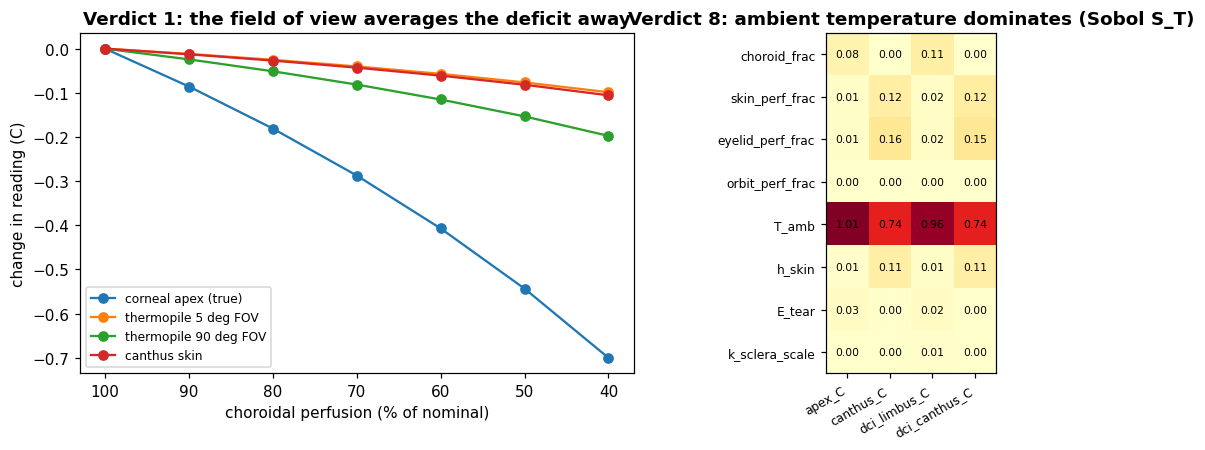

In [10]:
banner("PART 9  DIGITAL TWIN  --  credibility numbers (verification, validation, uncertainty)")
T = M["thermal"]; sw = v("thermal", "choroid_sweep"); base = sw[0]
t9 = pd.DataFrame([{"Quantity": "Corneal apex temperature (C), 25 C ambient", "Simulated": v("thermal", "corneal_apex_C"), "Published range": str(v("thermal", "published_corneal_apex_range_C"))},
                   {"Quantity": "Inner canthus skin temperature (C)", "Simulated": v("thermal", "medial_canthus_skin_C"), "Published range": str(v("thermal", "published_inner_canthus_range_C"))},
                   {"Quantity": "Temple skin temperature (C)", "Simulated": v("thermal", "temple_skin_C"), "Published range": ""},
                   {"Quantity": "MMS observed order of convergence (P1 tetrahedra)", "Simulated": v("verification", "observed_order"), "Published range": "theoretical 2"},
                   {"Quantity": "Largest grid convergence index (%)", "Simulated": v("verification", "gci_max_percent"), "Published range": "5 % typical acceptance"},
                   {"Quantity": "Apex deficit at 50 % choroidal perfusion (C)", "Simulated": v("thermal", "apex_deficit_at_50pct_choroid_C"), "Published range": "0.61 +/- 0.12 clinical NPDR deficit"},
                   {"Quantity": "Share of deficit seen by 90 deg thermopile", "Simulated": v("thermal", "thermopile_90deg_capture_fraction"), "Published range": ""},
                   {"Quantity": "Share of deficit seen by 5 deg thermopile", "Simulated": v("thermal", "thermopile_5deg_capture_fraction"), "Published range": ""},
                   {"Quantity": "Apex slope per C of ambient temperature", "Simulated": v("uq", "apex_slope_per_C_ambient"), "Published range": ""}])
print(t9.round(3).to_string(index=False)); t9.to_csv(NBO / "R9_Twin_Credibility.csv", index=False)
ST = np.array(v("uq", "ST")); params = [p[0] for p in v("uq", "params_ranges")]; outs = v("uq", "outputs")
t9b = pd.DataFrame(np.clip(ST, 0, None).round(3), index=params, columns=outs); print("\n  Total-order Sobol indices (rows inputs, columns readouts), 640 Saltelli solves:"); print(t9b.to_string()); t9b.to_csv(NBO / "R9_Sobol.csv")
gci = v("verification", "gci"); print("\n  GCI per quantity of interest (%):", {k: round(x["GCI_fine_percent"], 3) for k, x in gci.items()})
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
cf = [r["choroid_frac"] * 100 for r in sw]
for k, lab in (("apex_C", "corneal apex (true)"), ("dci_C", "thermopile 5 deg FOV"), ("baa_C", "thermopile 90 deg FOV"), ("canthus_C", "canthus skin")):
    ax[0].plot(cf, [r[k] - base[k] for r in sw], "o-", label=lab)
ax[0].invert_xaxis(); ax[0].set_xlabel("choroidal perfusion (% of nominal)"); ax[0].set_ylabel("change in reading (C)"); ax[0].legend(fontsize=8); ax[0].set_title("Verdict 1: the field of view averages the deficit away", fontweight="bold")
im = ax[1].imshow(np.clip(ST, 0, 1), cmap="YlOrRd", vmin=0, vmax=1); ax[1].set_xticks(range(len(outs))); ax[1].set_xticklabels(outs, rotation=30, ha="right", fontsize=8); ax[1].set_yticks(range(len(params))); ax[1].set_yticklabels(params, fontsize=8)
for i in range(ST.shape[0]):
    for j in range(ST.shape[1]): ax[1].text(j, i, f"{ST[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax[1].set_title("Verdict 8: ambient temperature dominates (Sobol S_T)", fontweight="bold")
plt.tight_layout(); plt.savefig(NBO / "R_Fig7_Twin.png", dpi=300, bbox_inches="tight"); plt.show()

In [11]:
banner("PART 10  DESIGN VERDICTS AND AUDIT SUMMARY  (headline numbers for the report)")
O = M["optical"]; B = M["bioimpedance"]; Pp = M["pupil"]; ss = v("pupil", "stimulus_sweep"); ed = v("bioimpedance", "edema_50kHz")
t10 = pd.DataFrame([
    ("1 Thermopile field of view", f"90 deg reads {v('thermal','thermopile_90deg_spot_mm'):.0f} mm spot, sees {100*v('thermal','thermopile_90deg_capture_fraction'):.0f} % of deficit; 5 deg sees {100*v('thermal','thermopile_5deg_capture_fraction'):.0f} %", "convert reading through the twin's transfer factor"),
    ("2 940 nm illuminator", f"pupil amplitude {ss[0]['amplitude_mm']:.2f} mm at 0 lx vs {[r for r in ss if r['stimulus_lux']==300][0]['amplitude_mm']:.2f} mm at 300 lx", "add a visible stimulus of at least 100 lx"),
    ("3 Thermopile aim", f"choroidal Sobol S_T {ST[params.index('choroid_frac'), outs.index('dci_limbus_C')]:.2f} at limbus vs {ST[params.index('choroid_frac'), outs.index('dci_canthus_C')]:.2f} at canthus", "aim at the ocular surface"),
    ("4 Contact impedance", f"{100*v('bioimpedance','bipolar_contact_share_of_total_50kHz'):.0f} % of a bipolar reading at 50 kHz", "tetrapolar drive and sense"),
    ("5 PPG spacing", f"arterial share {100*v('optical','ppg_by_wavelength','880','arterial_attenuation_share'):.1f} % at 880 nm, 3 mm; {100*v('optical','artery_share_of_pulse_at_12mm'):.0f} % at 12 mm with {v('optical','detected_fraction_ratio_3mm_over_12mm'):.0f}x fewer photons", "treat as a perfusion index"),
    ("6 Electrode geometry", f"local tetrapolar: orbit+eye+lid share {100*v('bioimpedance','orbit_share_50kHz'):.1f} %; +10 % orbital water -> {ed['0.1']['dZ_abs_percent']:.2f} % vs bipolar total {ed['0.1']['bipolar_total_dZ_abs_percent']:.2f} %", "four local electrodes per eye"),
    ("7 Illuminator heating", f"apex +{v('opto_thermal','apex_rise_at_iec_limit_C'):.2f} C at the {v('optical','led','max_led_optical_power_mW'):.1f} mW IEC limit = {100*v('opto_thermal','apex_rise_as_fraction_of_50pct_choroid_deficit'):.0f} % of the deficit", "pulse the illuminator, read thermopile with it off"),
    ("8 Ambient temperature", f"S_T {v('uq','ST_ambient_range')[0]:.2f} to {v('uq','ST_ambient_range')[1]:.2f}; apex {v('uq','apex_slope_per_C_ambient'):.2f} C per C ambient", "log ambient and compensate")],
    columns=["Verdict", "Quantity from the twin", "Design consequence"])
print(t10.to_string(index=False)); t10.to_csv(NBO / "R10_Verdicts.csv", index=False)
print("\n" + "=" * 78); print("AUDIT SUMMARY"); print("=" * 78)
print(f"  Fundus grader OOF                 : QWK {v('fundus_dr','qwk'):.3f}, referable AUC {v('fundus_dr','auc_referable'):.3f}")
print(f"  External IDRiD / APTOS            : AUC {v('fundus_external_idrid','auc_referable'):.3f} / {v('fundus_external_aptos','auc_referable'):.3f}; QWK {v('fundus_external_idrid','qwk'):.3f} / {v('fundus_external_aptos','qwk'):.3f}")
print(f"  APTOS boundary shift              : {100*t5.iloc[2]['graded above label (%)']/100:.1f} % graded above label; re-fitted QWK {v('fundus_external_aptos','refit_qwk_not_used'):.3f} (not used)")
print(f"  DME head test                     : QWK {v('dme','test_qwk'):.3f}, any-DME AUC {v('dme','test_auc_any_dme'):.3f}")
print(f"  EHR retinopathy / neuropathy      : AUC {v('ehr','retinopathy','hgb','auc'):.3f} / {v('ehr','headline_dn_auc'):.3f} (0.838 only with treatment proxies)")
print(f"  DR-DN co-occurrence               : OR {v('ehr','dr_dn_odds_ratio'):.2f}")
print(f"  HRV diabetes / retinopathy        : AUC {v('hrv','dm_vs_control','auc'):.3f} / {v('hrv','dr_within_dm','auc'):.3f} (null)")
print(f"  PPG diabetes / hypertension ctrl  : best route {v('ppg','diabetes_max_auc_any_route'):.3f} (null) / {v('ppg','hypertension_auc_by_route','morphology'):.3f}")
print(f"  Twin verification                 : MMS order {v('verification','observed_order'):.2f}; GCI at most {v('verification','gci_max_percent'):.1f} %")
print(f"  Twin uncertainty                  : ambient S_T {v('uq','ST_ambient_range')[0]:.2f} to {v('uq','ST_ambient_range')[1]:.2f}")
print("\n  CONCLUSION: the fundus grader keeps its ordering across populations but not its grade boundaries; routine records")
print("  give modest calibrated risk for both complications once treatment proxies are removed; heart-rate variability and")
print("  short fingertip PPG carry no retinopathy or diabetes signal here; the digital twin returns eight verdicts that changed")
print("  the hardware before it was built. No prototype has been tested on people.")
print("=" * 78)

PART 10  DESIGN VERDICTS AND AUDIT SUMMARY  (headline numbers for the report)
                   Verdict                                                                                Quantity from the twin                                 Design consequence
1 Thermopile field of view                                        90 deg reads 28 mm spot, sees 28 % of deficit; 5 deg sees 14 % convert reading through the twin's transfer factor
      2 940 nm illuminator                                                  pupil amplitude 0.10 mm at 0 lx vs 2.23 mm at 300 lx          add a visible stimulus of at least 100 lx
          3 Thermopile aim                                                 choroidal Sobol S_T 0.11 at limbus vs 0.00 at canthus                          aim at the ocular surface
       4 Contact impedance                                                                   68 % of a bipolar reading at 50 kHz                         tetrapolar drive and sense
             5 PPG spa